In [1]:
import os
import glob
import joblib
import pandas as pd
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt

# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)

In [2]:
class ImprovedLayeredClassifier(BaseEstimator, ClassifierMixin):
    """
    Enhanced two-layer classifier with multiple improvements:
    - Class-weighted logistic regression
    - Optimizable soft routing weights
    - Better feature representation
    - Threshold calibration
    """
    
    def __init__(self, max_features=10000, ngram_range=(1, 2), 
                 routing_strategy='soft', class_weight='balanced', 
                 random_state=42, solver='lbfgs', max_iter=100, penalty='l2'):
        self.max_features = max_features
        self.ngram_range = ngram_range
        self.random_state = random_state
        self.routing_strategy = routing_strategy  # 'soft', 'hard', 'weighted', 'ensemble'
        self.class_weight = class_weight
        self.solver = solver
        self.max_iter = max_iter
        self.penalty = penalty
        
        # Layer 1: Group classifier (with class weights)
        self.layer1_classifier = LogisticRegression(
            max_iter=max_iter, 
            random_state=random_state,
            class_weight=class_weight,
            solver=solver,
            penalty=penalty
        )
        
        # Layer 2: Fine-grained classifiers (with class weights)
        self.layer2a_classifier = LogisticRegression(
            max_iter=max_iter, 
            random_state=random_state,
            class_weight=class_weight,
            solver=solver,
            penalty=penalty
        )  # For 1/2/3
        self.layer2b_classifier = LogisticRegression(
            max_iter=max_iter, 
            random_state=random_state,
            class_weight=class_weight,
            solver=solver,
            penalty=penalty
        )  # For 3/4/5
        
        # Vectorizers with enhanced n-grams
        self.layer1_vectorizer = TfidfVectorizer(
            max_features=max_features, 
            ngram_range=ngram_range,
            min_df=2,  # Ignore very rare terms
            max_df=0.95  # Ignore very common terms
        )
        self.layer2a_vectorizer = TfidfVectorizer(
            max_features=max_features, 
            ngram_range=ngram_range,
            min_df=2,
            max_df=0.95
        )
        self.layer2b_vectorizer = TfidfVectorizer(
            max_features=max_features, 
            ngram_range=ngram_range,
            min_df=2,
            max_df=0.95
        )
        
        # Routing weights (can be optimized)
        self.routing_weights = None
    
    def fit(self, X, y, X_val=None, y_val=None):
        """
        Train the improved layered classifier.
        
        Args:
            X: Series of text reviews
            y: Series of star ratings (1-5)
            X_val: Optional validation set for routing optimization
            y_val: Optional validation labels
        """
        if not isinstance(X, pd.Series):
            X = pd.Series(X)
        if not isinstance(y, pd.Series):
            y = pd.Series(y)
        
        # print("\n" + "="*80)
        # print("TRAINING IMPROVED LAYERED CLASSIFIER")
        # print(f"Strategy: {self.routing_strategy.upper()} | Class Weight: {self.class_weight}")
        # print("="*80)
        
        # --- LAYER 1: BINARY GROUP CLASSIFIER ---
        # print("\n[LAYER 1] Training binary group classifier (1/2/3 vs 3/4/5)")
        # print("-" * 80)
        
        group_labels_list = []
        X_list = []
        
        mask_123 = y <= 3
        X_123 = X[mask_123]
        X_list.append(X_123)
        group_labels_list.append(np.zeros(len(X_123), dtype=int))
        
        mask_345 = y >= 3
        X_345 = X[mask_345]
        X_list.append(X_345)
        group_labels_list.append(np.ones(len(X_345), dtype=int))
        
        X_layer1 = pd.concat(X_list, ignore_index=True)
        group_labels = np.concatenate(group_labels_list)
        
        X_layer1_tfidf = self.layer1_vectorizer.fit_transform(X_layer1)
        self.layer1_classifier.fit(X_layer1_tfidf, group_labels)
        
        layer1_acc = accuracy_score(
            group_labels, self.layer1_classifier.predict(X_layer1_tfidf)
        )
        # print(f"  Training Accuracy: {layer1_acc:.4f}")
        # print(f"  Samples: {len(X_layer1)} (Group 0: {(group_labels==0).sum()}, "
        #       f"Group 1: {(group_labels==1).sum()})")
        
        # --- LAYER 2A: FINE CLASSIFIER FOR 1/2/3 ---
        # print("\n[LAYER 2A] Training fine classifier for 1/2/3 stars")
        # print("-" * 80)
        
        mask_123_fine = y <= 3
        X_123_fine = X[mask_123_fine]
        y_123_fine = y[mask_123_fine]
        
        X_123_tfidf = self.layer2a_vectorizer.fit_transform(X_123_fine)
        self.layer2a_classifier.fit(X_123_tfidf, y_123_fine)
        
        layer2a_acc = accuracy_score(
            y_123_fine, self.layer2a_classifier.predict(X_123_tfidf)
        )
        # print(f"  Training Accuracy: {layer2a_acc:.4f}")
        # print(f"  Samples: {len(X_123_fine)} (1: {(y_123_fine==1).sum()}, "
        #       f"2: {(y_123_fine==2).sum()}, 3: {(y_123_fine==3).sum()})")
        
        # --- LAYER 2B: FINE CLASSIFIER FOR 3/4/5 ---
        # print("\n[LAYER 2B] Training fine classifier for 3/4/5 stars")
        # print("-" * 80)
        
        mask_345_fine = y >= 3
        X_345_fine = X[mask_345_fine]
        y_345_fine = y[mask_345_fine]
        
        X_345_tfidf = self.layer2b_vectorizer.fit_transform(X_345_fine)
        self.layer2b_classifier.fit(X_345_tfidf, y_345_fine)
        
        layer2b_acc = accuracy_score(
            y_345_fine, self.layer2b_classifier.predict(X_345_tfidf)
        )
        # print(f"  Training Accuracy: {layer2b_acc:.4f}")
        # print(f"  Samples: {len(X_345_fine)} (3: {(y_345_fine==3).sum()}, "
        #       f"4: {(y_345_fine==4).sum()}, 5: {(y_345_fine==5).sum()})")
        
        # Optional: Optimize routing weights on validation set
        if X_val is not None and y_val is not None:
            print("\n[OPTIMIZATION] Optimizing routing weights on validation set...")
            self._optimize_routing_weights(X_val, y_val)
        else:
            self.routing_weights = np.array([0.5, 0.5])  # Default equal weights
        
        # print("\n" + "="*80)
        # print("Training Complete")
        # print("="*80 + "\n")
        
        return self
    
    def _optimize_routing_weights(self, X_val, y_val):
        """
        Optimize the soft routing weights using validation set.
        """
        def objective(w1):
            w = np.array([w1, 1 - w1])
            self.routing_weights = w
            preds = self.predict(X_val)
            return -f1_score(y_val, preds, average='weighted')
        
        result = minimize_scalar(objective, bounds=(0.2, 0.8), method='bounded')
        self.routing_weights = np.array([result.x, 1 - result.x])
        print(f"  Optimized weights: Group0={self.routing_weights[0]:.4f}, "
              f"Group1={self.routing_weights[1]:.4f}")
    
    def predict_proba(self, X):
        """
        Predict probabilities using the specified routing strategy.
        """
        if not isinstance(X, pd.Series):
            X = pd.Series(X)
        
        # Layer 1 predictions
        X_layer1_tfidf = self.layer1_vectorizer.transform(X)
        group_proba = self.layer1_classifier.predict_proba(X_layer1_tfidf)
        
        # Layer 2 predictions
        X_layer2a_tfidf = self.layer2a_vectorizer.transform(X)
        X_layer2b_tfidf = self.layer2b_vectorizer.transform(X)
        
        proba_123 = self.layer2a_classifier.predict_proba(X_layer2a_tfidf)
        proba_345 = self.layer2b_classifier.predict_proba(X_layer2b_tfidf)
        
        classes_123 = self.layer2a_classifier.classes_
        classes_345 = self.layer2b_classifier.classes_
        
        # Initialize combined probabilities
        combined_proba = np.zeros((len(X), 5))
        
        if self.routing_strategy == 'soft':
            # Soft routing: weighted combination using group probabilities
            weights = self.routing_weights if self.routing_weights is not None else np.array([0.5, 0.5])
            for i, class_label in enumerate(classes_123):
                combined_proba[:, class_label - 1] += weights[0] * proba_123[:, i]
            for i, class_label in enumerate(classes_345):
                combined_proba[:, class_label - 1] += weights[1] * proba_345[:, i]
        
        elif self.routing_strategy == 'dynamic':
            # Dynamic routing: use actual group probabilities as weights
            for i, class_label in enumerate(classes_123):
                combined_proba[:, class_label - 1] += group_proba[:, 0] * proba_123[:, i]
            for i, class_label in enumerate(classes_345):
                combined_proba[:, class_label - 1] += group_proba[:, 1] * proba_345[:, i]
        
        elif self.routing_strategy == 'hard':
            # Hard routing: pick one path based on group prediction
            group_preds = self.layer1_classifier.predict(X_layer1_tfidf)
            for i in range(len(X)):
                if group_preds[i] == 0:
                    for j, class_label in enumerate(classes_123):
                        combined_proba[i, class_label - 1] = proba_123[i, j]
                else:
                    for j, class_label in enumerate(classes_345):
                        combined_proba[i, class_label - 1] = proba_345[i, j]
        
        elif self.routing_strategy == 'ensemble':
            # Ensemble: average both paths equally
            for i, class_label in enumerate(classes_123):
                combined_proba[:, class_label - 1] += 0.5 * proba_123[:, i]
            for i, class_label in enumerate(classes_345):
                combined_proba[:, class_label - 1] += 0.5 * proba_345[:, i]
        
        # Normalize
        combined_proba = combined_proba / combined_proba.sum(axis=1, keepdims=True)
        
        return combined_proba
    
    def predict(self, X):
        proba = self.predict_proba(X)
        return np.argmax(proba, axis=1) + 1

In [3]:
def load_data(folder_path='../Preprocessing-FeatureExtraction/cleaned-data'):
    csv_files = glob.glob(os.path.join(folder_path, '*.csv'))
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in {folder_path}")
    
    dfs = []
    for file in csv_files:
        df = pd.read_csv(file)
        dfs.append(df)
    
    data = pd.concat(dfs, ignore_index=True)
    data = data.dropna(subset=['stars', 'clean_text'])
    data['stars'] = data['stars'].astype(int)
    return data

In [4]:
def stratified_manual_split(X, y, train_size=200000, val_size=25000, test_size=25000, random_state=42):
    total_size = min(train_size + val_size + test_size, len(X))
    X = X.reset_index(drop=True)
    y = y.reset_index(drop=True)

    X_train_parts, X_val_parts, X_test_parts = [], [], []
    y_train_parts, y_val_parts, y_test_parts = [], [], []

    rng = np.random.RandomState(random_state)

    for star_class in sorted(y.unique()):
        mask = (y == star_class)
        X_class = X[mask].reset_index(drop=True)
        y_class = y[mask].reset_index(drop=True)

        n_class = len(y_class)
        if n_class == 0:
            continue

        n_train_c = max(15, int(n_class * train_size / total_size))
        n_val_c = max(5, int(n_class * val_size / total_size))
        n_test_c = max(5, n_class - n_train_c - n_val_c)

        indices = rng.permutation(n_class)

        X_train_parts.append(X_class.iloc[indices[:n_train_c]])
        y_train_parts.append(y_class.iloc[indices[:n_train_c]])

        val_end = n_train_c + n_val_c
        X_val_parts.append(X_class.iloc[indices[n_train_c:val_end]])
        y_val_parts.append(y_class.iloc[indices[n_train_c:val_end]])

        X_test_parts.append(X_class.iloc[val_end:val_end + n_test_c])
        y_test_parts.append(y_class.iloc[val_end:val_end + n_test_c])

    X_train = pd.concat(X_train_parts, ignore_index=True)
    y_train = pd.concat(y_train_parts, ignore_index=True)
    X_val = pd.concat(X_val_parts, ignore_index=True)
    y_val = pd.concat(y_val_parts, ignore_index=True)
    X_test = pd.concat(X_test_parts, ignore_index=True)
    y_test = pd.concat(y_test_parts, ignore_index=True)

    return X_train, y_train, X_val, y_val, X_test, y_test

In [5]:
def tune_hyperparameters(
    data,
    param_grid,
    train_size=200000,
    val_size=25000,
    test_size=25000,
    scoring='macro_f1',   # 'weighted_f1' or 'accuracy' or 'macro_f1'
    results_csv='tuning_results_hard_routing.csv',
    best_model_path='best_improved_layered_hard.joblib',
    random_state=42
):
    # Prepare dataset
    total_size = min(train_size + val_size + test_size, len(data))
    print(f"Sampling {total_size} reviews for tuning...")
    samples_per_class = min(total_size // data['stars'].nunique(), data['stars'].value_counts().min())
    data_sample = (
        data.groupby('stars', group_keys=False)
            .apply(lambda x: x.sample(n=samples_per_class))
            .reset_index(drop=True)
    )
    
    print()
    print(f"\nBalanced class distribution:")
    print(data_sample['stars'].value_counts().sort_index())
    print()

    X = data_sample['clean_text'].reset_index(drop=True)
    y = data_sample['stars'].astype(int).reset_index(drop=True)

    X_train, y_train, X_val, y_val, X_test, y_test = stratified_manual_split(
        X, y, train_size=train_size, val_size=val_size, test_size=test_size, random_state=random_state
    )

    print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

    # ParameterGrid iteration
    grid = list(ParameterGrid(param_grid))
    print(f"Total combinations: {len(grid)}")

    rows = []
    best_score = -np.inf
    best_entry = None
    i = 1

    for params in tqdm(grid):

        print(params)
        # Build classifier with hard routing
        clf = ImprovedLayeredClassifier(
            max_features=params.get('max_features', 10000),
            ngram_range=params.get('ngram_range', (1,2)),
            routing_strategy='hard',
            class_weight=params.get('balanced'),
            random_state=random_state,
            solver=params.get('solver', 'lbfgs'),
            max_iter=params.get('max_iter', 100),
            penalty=params.get('penalty', 'l2')
        )

        min_df = params.get('min_df', 2)
        max_df = params.get('max_df', 0.95)
        max_features = params.get('max_features', 10000)
        ngram_range = params.get('ngram_range', (1,2))
        use_idf = params.get('use_idf', True)
        sublinear_tf = params.get('sublinear_tf', True)

        clf.layer1_vectorizer = TfidfVectorizer(max_features=max_features, ngram_range=ngram_range,
                                                min_df=min_df, max_df=max_df, use_idf=use_idf, 
                                                sublinear_tf=sublinear_tf)
        clf.layer2a_vectorizer = TfidfVectorizer(max_features=max_features, ngram_range=ngram_range,
                                                 min_df=min_df, max_df=max_df, use_idf=use_idf, 
                                                sublinear_tf=sublinear_tf)
        clf.layer2b_vectorizer = TfidfVectorizer(max_features=max_features, ngram_range=ngram_range,
                                                 min_df=min_df, max_df=max_df, use_idf=use_idf, 
                                                sublinear_tf=sublinear_tf)

        # Update classifier objects (before fit)
        clf.layer1_classifier.C = params.get('C_layer1', 1.0)
        clf.layer2a_classifier.C = params.get('C_layer2a', 1.0)
        clf.layer2b_classifier.C = params.get('C_layer2b', 1.0)

        # Fit
        try:
            clf.fit(X_train, y_train)
        except Exception as e:
            print(f"Failed to fit for params {params}: {e}")
            continue

        # Validate
        y_val_pred = clf.predict(X_val)

        acc = accuracy_score(y_val, y_val_pred)
        weighted_f1 = f1_score(y_val, y_val_pred, average='weighted')
        macro_f1 = f1_score(y_val, y_val_pred, average='macro')

        report = classification_report(y_val, y_val_pred, labels=[1,2,3,4,5], output_dict=True, zero_division=0)

        if scoring == 'weighted_f1':
            score = weighted_f1
        elif scoring == 'macro_f1':
            score = macro_f1
        else:
            score = acc

        row = {
            **params,
            'val_accuracy': acc,
            'val_macro_f1': macro_f1,
            'val_weighted_f1': weighted_f1,
            'score': score,
            'report': report
        }
        rows.append(row)

        # Keep best
        if score > best_score:
            best_score = score
            best_entry = {
                'params': params,
                'clf': clf,
                'val_accuracy': acc,
                'val_macro_f1': macro_f1,
                'val_weighted_f1': weighted_f1
            }

        print()
        print(f'Iteration: {i}')
        print(f'Test Accuracy: {score*100:.2f}%')
        print()
        i += 1

    # Save results
    df_rows = []
    for r in rows:
        flat = {k: v for k, v in r.items() if k != 'report'}
        # Add per-class F1 if available
        rep = r.get('report', {})
        for star in [1,2,3,4,5]:
            key = f'f1_{star}'
            flat[key] = rep.get(str(star), {}).get('f1-score', np.nan)
        df_rows.append(flat)

    results_df = pd.DataFrame(df_rows)
    results_df.to_csv(results_csv, index=False)
    print(f"Saved tuning results to {results_csv}")

    # Save best model
    if best_entry is not None:
        joblib.dump(best_entry['clf'], best_model_path)
        print(f"Best params: {best_entry['params']}")
        print(f"Best validation score ({scoring}): {best_score:.4f}")
        print(f"Saved best model to {best_model_path}")

        # Evaluate best on test set and print summary
        best_clf = best_entry['clf']
        y_test_pred = best_clf.predict(X_test)
        test_acc = accuracy_score(y_test, y_test_pred)
        test_weighted_f1 = f1_score(y_test, y_test_pred, average='weighted')
        test_macro_f1 = f1_score(y_test, y_test_pred, average='macro')

        print("\n=== BEST MODEL TEST EVAL ===")
        print(f"Test Accuracy: {test_acc:.4f}")
        print(f"Test Weighted-F1: {test_weighted_f1:.4f}")
        print(f"Test Macro-F1: {test_macro_f1:.4f}")

        test_report = classification_report(y_test, y_test_pred, labels=[1,2,3,4,5])
        print(test_report)

        cm = confusion_matrix(y_test, y_test_pred, labels=[1, 2, 3, 4, 5])
        # Normalized confusion matrix
        cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        # Raw counts
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=[1,2,3,4,5], yticklabels=[1,2,3,4,5], ax=axes[0],
                    cbar_kws={'label': 'Count'})
        axes[0].set_title('Confusion Matrix - Raw Counts', fontsize=13, fontweight='bold')
        axes[0].set_ylabel('True Label')
        axes[0].set_xlabel('Predicted Label')

        # Normalized
        sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='RdYlGn',
                    xticklabels=[1,2,3,4,5], yticklabels=[1,2,3,4,5], ax=axes[1],
                    cbar_kws={'label': 'Percentage'}, vmin=0, vmax=1)
        axes[1].set_title('Confusion Matrix - Normalized (% by true class)', fontsize=13, fontweight='bold')
        axes[1].set_ylabel('True Label')
        axes[1].set_xlabel('Predicted Label')

        plt.tight_layout()
        plt.show()

        # Per-class analysis
        print("\nPer-Class Breakdown:")
        for i, star in enumerate([1, 2, 3, 4, 5]):
            correct = cm[i, i]
            total = cm[i].sum()
            print(f"\n{star}-Star Reviews (n={total}):")
            print(f"  Correct: {correct}/{total} ({100*correct/total:.1f}%)")
            for j, pred_star in enumerate([1, 2, 3, 4, 5]):
                if i != j and cm[i, j] > 0:
                    print(f"  Misclassified as {pred_star}: {cm[i, j]} ({100*cm[i, j]/total:.1f}%)")

    else:
        print("No successful runs; no best model saved.")

    return results_df, best_entry

Sampling 250000 reviews for tuning...


Balanced class distribution:
1    50000
2    50000
3    50000
4    50000
5    50000
Name: stars, dtype: int64

Train: 200000 | Val: 25000 | Test: 25000
Total combinations: 192


  0%|          | 0/192 [00:00<?, ?it/s]

{'C_layer1': 1.0, 'C_layer2a': 1.0, 'C_layer2b': 1.0, 'class_weight': None, 'max_df': 0.9, 'max_features': 10000, 'max_iter': 300, 'min_df': 1, 'ngram_range': (1, 2), 'penalty': 'l2', 'solver': 'lbfgs', 'sublinear_tf': True, 'use_idf': True}


/Users/juliasober/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
  1%|          | 1/192 [01:32<4:55:15, 92.75s/it]


Iteration: 1
Test Accuracy: 61.12%

{'C_layer1': 1.0, 'C_layer2a': 1.0, 'C_layer2b': 1.0, 'class_weight': None, 'max_df': 0.9, 'max_features': 10000, 'max_iter': 300, 'min_df': 1, 'ngram_range': (1, 3), 'penalty': 'l2', 'solver': 'lbfgs', 'sublinear_tf': True, 'use_idf': True}


...

/Users/juliasober/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/juliasober/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#l


Iteration: 191
Test Accuracy: 58.47%

{'C_layer1': 10.0, 'C_layer2a': 10.0, 'C_layer2b': 10.0, 'class_weight': None, 'max_df': 0.95, 'max_features': 20000, 'max_iter': 300, 'min_df': 3, 'ngram_range': (1, 3), 'penalty': 'l2', 'solver': 'lbfgs', 'sublinear_tf': True, 'use_idf': True}


/Users/juliasober/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/juliasober/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#l


Iteration: 192
Test Accuracy: 58.58%

Saved tuning results to tuning_results_hard_routing.csv


Best params: {'C_layer1': 1.0, 'C_layer2a': 1.0, 'C_layer2b': 1.0, 'class_weight': None, 'max_df': 0.9, 'max_features': 10000, 'max_iter': 300, 'min_df': 3, 'ngram_range': (1, 3), 'penalty': 'l2', 'solver': 'lbfgs', 'sublinear_tf': True, 'use_idf': True}
Best validation score (macro_f1): 0.6126
Saved best model to best_improved_layered_hard.joblib

=== BEST MODEL TEST EVAL ===
Test Accuracy: 0.6671
Test Weighted-F1: 0.6656
Test Macro-F1: 0.6656
              precision    recall  f1-score   support

           1       0.75      0.78      0.77      5000
           2       0.62      0.59      0.60      5000
           3       0.61      0.61      0.61      5000
           4       0.61      0.58      0.60      5000
           5       0.73      0.77      0.75      5000

    accuracy                           0.67     25000
   macro avg       0.66      0.67      0.67     25000
weighted avg       0.66      0.67      0.67     25000



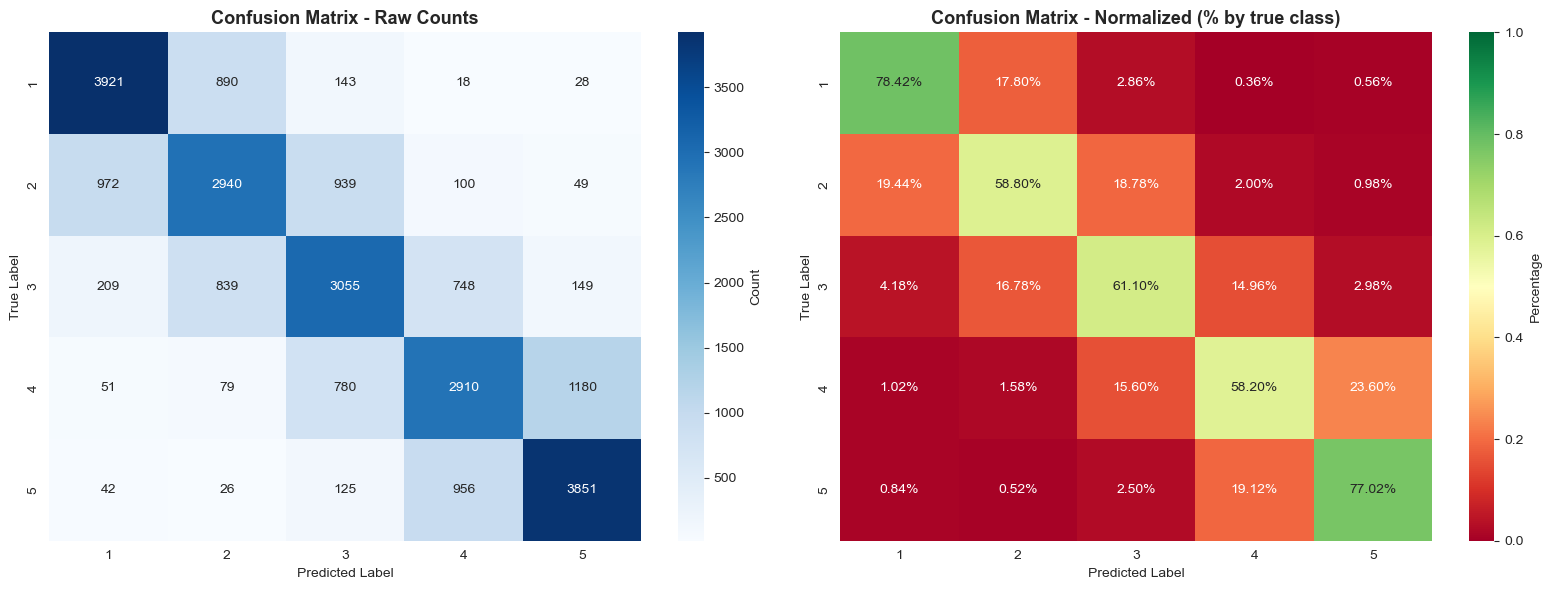


Per-Class Breakdown:

1-Star Reviews (n=5000):
  Correct: 3921/5000 (78.4%)
  Misclassified as 2: 890 (17.8%)
  Misclassified as 3: 143 (2.9%)
  Misclassified as 4: 18 (0.4%)
  Misclassified as 5: 28 (0.6%)

2-Star Reviews (n=5000):
  Correct: 2940/5000 (58.8%)
  Misclassified as 1: 972 (19.4%)
  Misclassified as 3: 939 (18.8%)
  Misclassified as 4: 100 (2.0%)
  Misclassified as 5: 49 (1.0%)

3-Star Reviews (n=5000):
  Correct: 3055/5000 (61.1%)
  Misclassified as 1: 209 (4.2%)
  Misclassified as 2: 839 (16.8%)
  Misclassified as 4: 748 (15.0%)
  Misclassified as 5: 149 (3.0%)

4-Star Reviews (n=5000):
  Correct: 2910/5000 (58.2%)
  Misclassified as 1: 51 (1.0%)
  Misclassified as 2: 79 (1.6%)
  Misclassified as 3: 780 (15.6%)
  Misclassified as 5: 1180 (23.6%)

5-Star Reviews (n=5000):
  Correct: 3851/5000 (77.0%)
  Misclassified as 1: 42 (0.8%)
  Misclassified as 2: 26 (0.5%)
  Misclassified as 3: 125 (2.5%)
  Misclassified as 4: 956 (19.1%)

Tuning complete. Top 5 configurations by

In [6]:
if __name__ == '__main__':
    # Load data
    data = load_data()

    # Define parameter grid to search over
    param_grid = {
        'max_features': [10000, 20000],
        'ngram_range': [(1,2), (1,3)],
        'min_df': [1, 2, 3],  
        'max_df': [0.9, 0.95],  
        'class_weight': [None],
        'C_layer1': [1.0, 10.0],
        'C_layer2a': [1.0, 10.0],
        'C_layer2b': [1.0, 10.0],
        'solver': ['lbfgs'],
        'max_iter': [300],
        'penalty': ['l2'],
        'use_idf': [True],          
        'sublinear_tf': [True],
    }

    # Run tuning
    results_df, best = tune_hyperparameters(
        data,
        param_grid=param_grid,
        train_size=200000,  
        val_size=25000,
        test_size=25000,
        scoring='macro_f1',
        results_csv='tuning_results_hard_routing.csv',
        best_model_path='best_improved_layered_hard.joblib',
        random_state=42
    )

    print("\nTuning complete. Top 5 configurations by score:")
    print(results_df.sort_values('score', ascending=False).head(5))